In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

In [5]:
df = pd.read_csv("../data/SampleSuperstore.csv")

df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [6]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   str    
 1   Segment       9994 non-null   str    
 2   Country       9994 non-null   str    
 3   City          9994 non-null   str    
 4   State         9994 non-null   str    
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   str    
 7   Category      9994 non-null   str    
 8   Sub-Category  9994 non-null   str    
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), str(8)
memory usage: 1015.1 KB


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [7]:
# Remover duplicados
df = df.drop_duplicates()

# Verificar novamente
df.duplicated().sum()

np.int64(0)

In [9]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales: {total_sales}")
print(f"Total Profit: {total_profit}")

Total Sales: 2296195.5903
Total Profit: 286241.42260000005


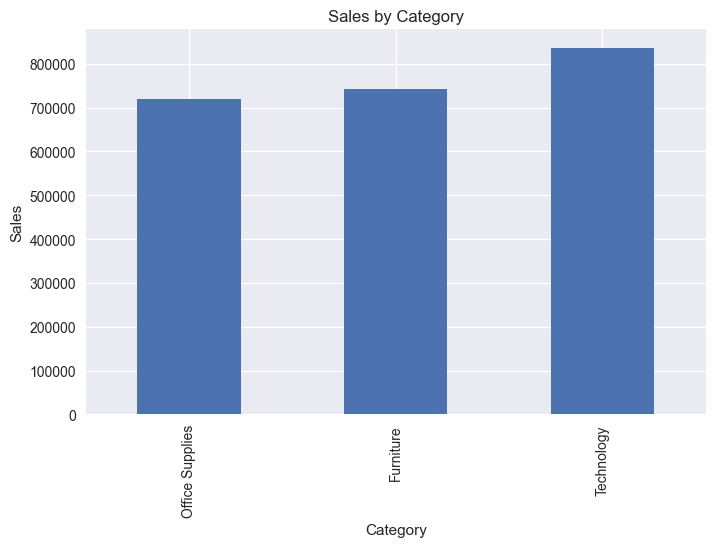

In [10]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()

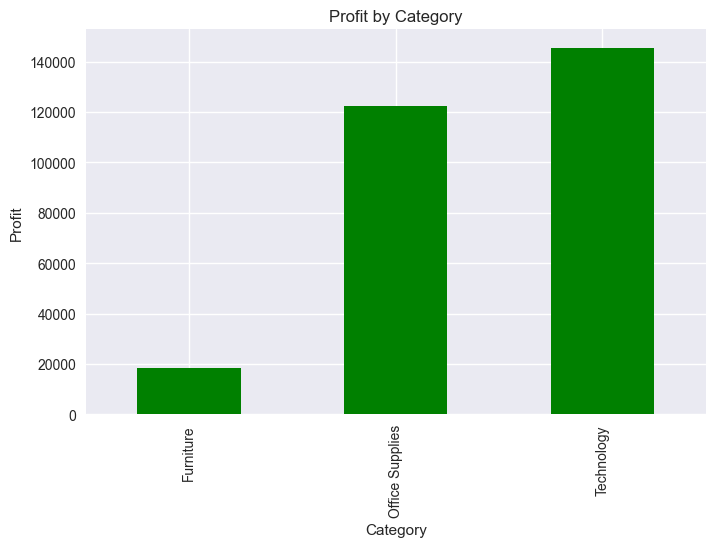

In [11]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

category_profit.plot(kind='bar', color='green', figsize=(8,5))
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.show()

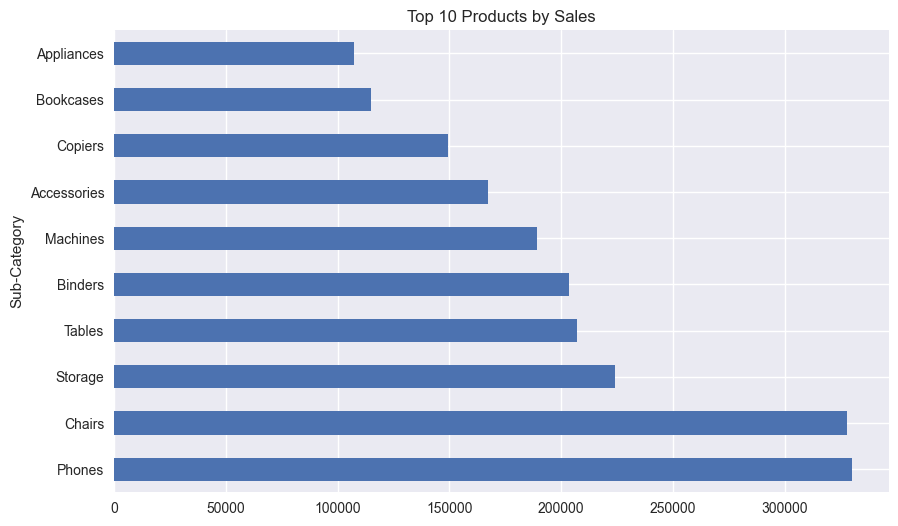

In [12]:
top_products = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh', figsize=(10,6))
plt.title("Top 10 Products by Sales")
plt.show()

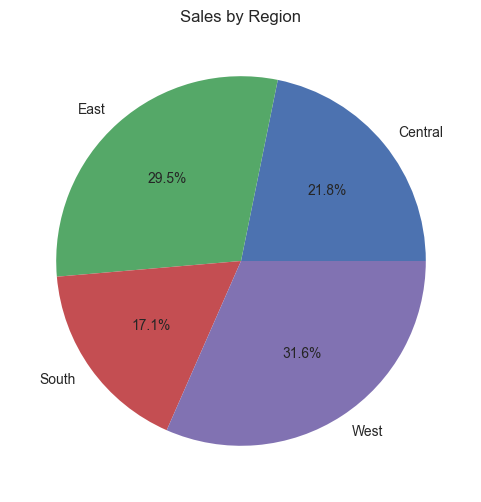

In [13]:
region_sales = df.groupby('Region')['Sales'].sum()

region_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))
plt.title("Sales by Region")
plt.ylabel("")
plt.show()

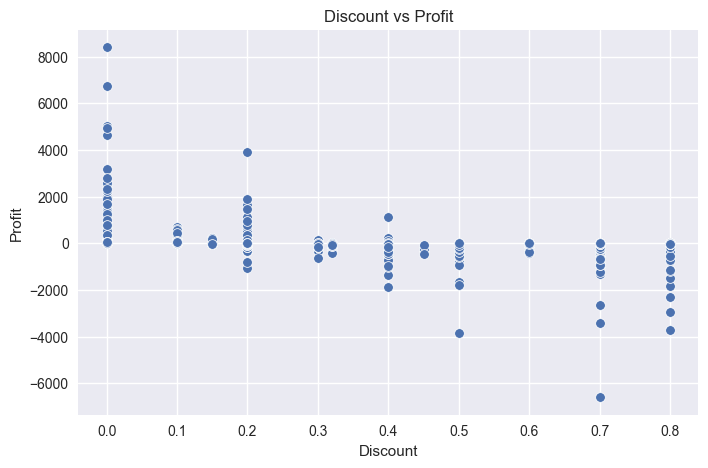

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.title("Discount vs Profit")
plt.show()

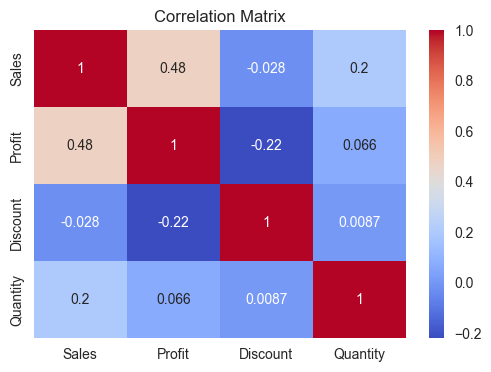

In [15]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Sales', 'Profit', 'Discount', 'Quantity']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()